Found 650 CSV files


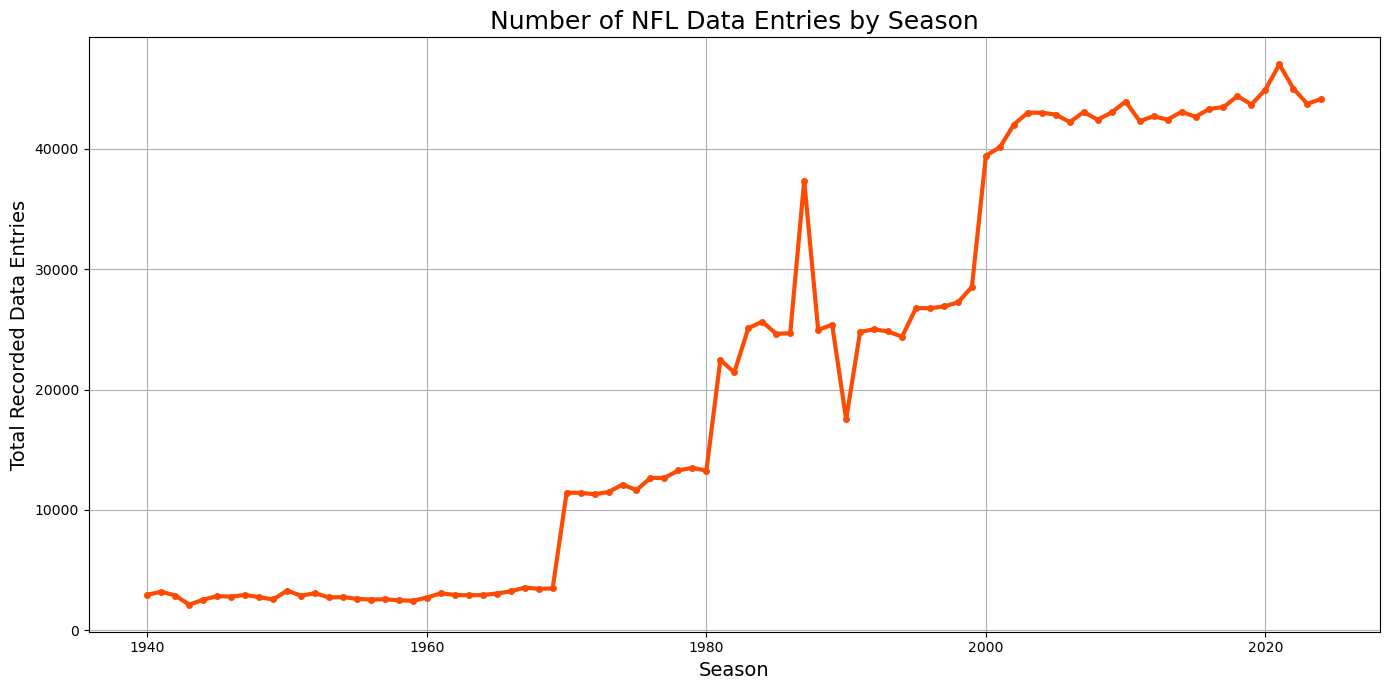

In [6]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt

year_totals = {year: 0 for year in range(1940, 2025)}

# Let's begin by finding all the .csv files (searching all the subfolders)
csv_files = glob.glob("../**/*.csv", recursive=True)

# Quick sanity check
print(f"Found {len(csv_files)} CSV files")

for filename in csv_files:

    match = re.search(r'(\d{4})', filename)

    if not match:
        continue

    year = int(match.group(1))
    df = pd.read_csv(filename, dtype=str)
    rows, cols = df.shape
    total_entries = rows * cols
    year_totals[year] += total_entries

# Now it's time to graph it!

years = list(year_totals.keys())
totals = list(year_totals.values())

plt.figure(figsize=(14,7))
plt.plot(years, totals, linewidth=3, marker='o', markersize=4, color='xkcd:blood orange')
plt.title("Number of NFL Data Entries by Season", fontsize=18)
plt.xlabel("Season", fontsize=14)
plt.ylabel("Total Recorded Data Entries", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()